___

**[ Machine Learning in Geosciences ]**

**Department of Applied Geoinformatics and Carthography, Charles University** 

*Lukas Brodsky lukas.brodsky@natur.cuni.cz*


___

**Exercise: make assumption from data -> select ML algorithm**

**Task**: 
* Don’t pick algorithms from memory.
* Diagnose the data-generating process and justify the model.

There are 5 generated synthetic geoscience datasets, each violating a different assumption.

**You must**:
1. Inspect data (plots)
2. Choose model
3. Train
4. Evaluate
5. Explain why it works

All datasets are low-dimensional → visual intuition first.

**Imports**

In [1]:
print('hello world')

hello world


In [2]:
# Common imports & ML models 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

# Linear regression 
from sklearn.linear_model import LinearRegression
# KNN 
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
# DT 
from sklearn.tree import DecisionTreeClassifier
# SVM 
from sklearn.svm import SVC
# ANN - MLP 
from sklearn.neural_network import MLPClassifier
# clustering DBSCAN 
from sklearn.cluster import DBSCAN

In [3]:
def plot_decision_boundary(model, X, y, title="Model", resolution=300):

    n_features = model.n_features_in_

    # ---- 1D ----
    if n_features == 1:
        xs = np.linspace(X.min()-1, X.max()+1, resolution).reshape(-1,1)

        if hasattr(model, "predict_proba"):
            preds = model.predict_proba(xs)[:,1]
        else:
            preds = model.predict(xs)

        plt.figure(figsize=(6,4))
        plt.scatter(X[:,0], y, c=y, cmap="coolwarm", s=25)
        plt.plot(xs, preds, color="black", linewidth=2)
        plt.title(title)
        plt.show()
        return

    # ---- 2D ----
    if n_features == 2:
        x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
        y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict(grid).reshape(xx.shape)

        plt.figure(figsize=(6,5))
        plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
        plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k")
        plt.title(title)
        plt.show()

# **Dataset A**

Temperature vs elevation

In [4]:
# Data
np.random.seed(0)
x = np.random.uniform(0, 3000, 150)
y = 15 - 0.0065*x + np.random.normal(0, 1.0, 150)

X = x.reshape(-1,1)
Xtr,Xte,Ytr,Yte = train_test_split(X,y,test_size=0.3)

In [5]:
Xtr.shape

(105, 1)

In [6]:
Ytr.shape

(105,)

In [7]:
Xte.shape

(45, 1)

In [8]:
Yte.shape

(45,)

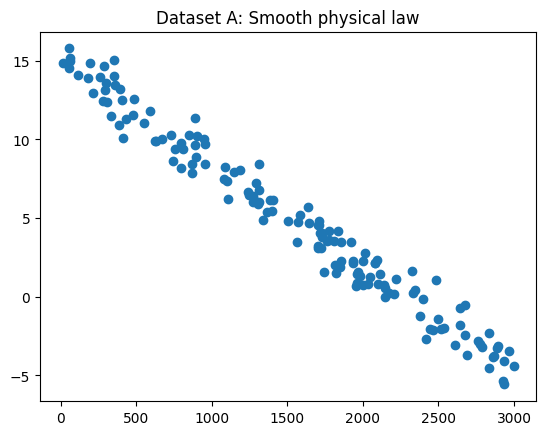

In [9]:
# Data plot 
plt.scatter(x,y)
# plt.plot(np.sort(x), lr.predict(np.sort(X,axis=0)), color='red')
plt.title("Dataset A: Smooth physical law")
plt.show()

**What is the global relation?**  → LINEAR

In [10]:
# Select model and create an instance 
model = LinearRegression()
# Model fit 
model.fit(Xtr, Ytr)
# Model prediction 
Y_pred = model.predict(Xte)
# Model evaluation
mean_squared_error(Yte, Y_pred)

0.6897677208791585

In [11]:
# Y_pred

In [12]:
X_sim = np.linspace(0, 3000, 100)

In [13]:
X_sim.reshape(-1,1).shape

(100, 1)

In [14]:
Xtr.shape

(105, 1)

In [15]:
# How? 
Y_pred_sim = model.predict(X_sim.reshape(-1,1))

In [24]:
Y_pred_sim

array([15.00712831, 14.80831311, 14.6094979 , 14.4106827 , 14.21186749,
       14.01305229, 13.81423708, 13.61542188, 13.41660667, 13.21779147,
       13.01897626, 12.82016106, 12.62134585, 12.42253065, 12.22371544,
       12.02490024, 11.82608503, 11.62726983, 11.42845462, 11.22963942,
       11.03082421, 10.83200901, 10.6331938 , 10.4343786 , 10.23556339,
       10.03674819,  9.83793298,  9.63911778,  9.44030257,  9.24148737,
        9.04267216,  8.84385696,  8.64504175,  8.44622655,  8.24741134,
        8.04859614,  7.84978093,  7.65096573,  7.45215052,  7.25333532,
        7.05452011,  6.85570491,  6.6568897 ,  6.4580745 ,  6.25925929,
        6.06044409,  5.86162888,  5.66281368,  5.46399847,  5.26518327,
        5.06636806,  4.86755286,  4.66873765,  4.46992245,  4.27110724,
        4.07229204,  3.87347683,  3.67466163,  3.47584642,  3.27703122,
        3.07821601,  2.87940081,  2.6805856 ,  2.4817704 ,  2.28295519,
        2.08413999,  1.88532478,  1.68650958,  1.48769437,  1.28

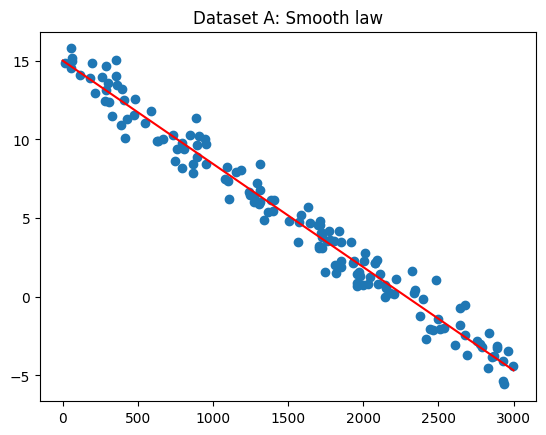

In [16]:
# Model plot
plt.scatter(x,y)
plt.plot(X_sim, Y_pred_sim, color='red')
plt.title("Dataset A: Smooth law")
plt.show()

# **Dataset B** 


In [17]:
# Data: environmental feature space (3 variables)
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)
n = 300

# environmental feature space
c1 = np.random.normal(loc=[-2,-1], scale=0.6, size=(n//3,2))
c2 = np.random.normal(loc=[2,1.5], scale=0.7, size=(n//3,2))
c3 = np.random.normal(loc=[0,3], scale=0.5, size=(n//3,2))

X = np.vstack([c1,c2,c3])

In [18]:
X.shape

(300, 2)

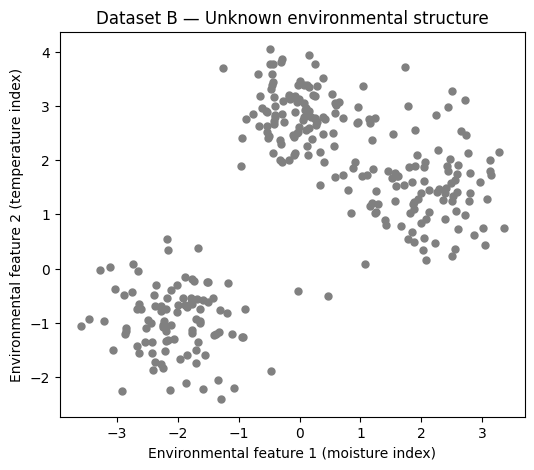

In [19]:
# Plot data 
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], color="gray", s=25)
plt.xlabel("Environmental feature 1 (moisture index)")
plt.ylabel("Environmental feature 2 (temperature index)")
plt.title("Dataset B — Unknown environmental structure")
plt.show()

In [20]:
from sklearn.cluster import DBSCAN
# Select model and create an instance 
model = DBSCAN(eps=1.0) # eps=0.5
# Model fit 
model.fit(X)
# prediction 
y_labels = model.fit_predict(X)

In [21]:
model

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1.0
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [22]:
np.unique(model.labels_)

array([0, 1])

In [24]:
# model.labels_
model.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [25]:
y_labels = model.fit_predict(X)

In [26]:
# y_labels
y_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [27]:
# plot_decision_boundary(model, X, y_labels, "similarity-based classification")
plot_decision_boundary(model, X, y_labels, "similarity-based classification")

AttributeError: 'DBSCAN' object has no attribute 'predict'

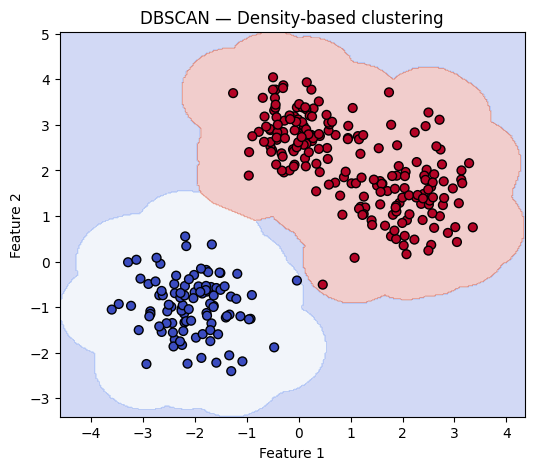

In [28]:
# Decision boundary for DBSCAN 
from scipy.spatial.distance import cdist 

# core samples
core_points = X[model.core_sample_indices_]
core_labels = y_labels[model.core_sample_indices_]

# -----------------------------
# Create grid for visualization
# -----------------------------
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# -----------------------------
# Assign grid points to clusters
# -----------------------------
distances = cdist(grid, core_points)

nearest_core = distances.argmin(axis=1)
nearest_dist = distances.min(axis=1)

Z = np.full(len(grid), -1)

for i in range(len(grid)):
    if nearest_dist[i] <= model.eps:
        Z[i] = core_labels[nearest_core[i]]

Z = Z.reshape(xx.shape)

# -----------------------------
# Plot decision regions
# -----------------------------
plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

plt.scatter(
    X[:,0], X[:,1],
    c=y_labels,
    cmap="coolwarm",
    edgecolor="k",
    s=40
)

plt.title("DBSCAN — Density-based clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# **Dataset C**

In [29]:
# Data 
np.random.seed(3)
n = 400

# environmental variables
elevation = np.random.uniform(0,3000,n)
moisture = np.random.uniform(0,1,n)

X = np.column_stack([elevation, moisture])

# environmental regimes
y = np.zeros(n)
# agriculture
y[(elevation < 800) & (moisture > 0.4)] = 0
# forest
y[(elevation >= 800) & (elevation < 1800)] = 1
# rock
y[(elevation >= 1800) & (moisture < 0.5)] = 2
# snow
y[(elevation >= 1800) & (moisture >= 0.5)] = 3

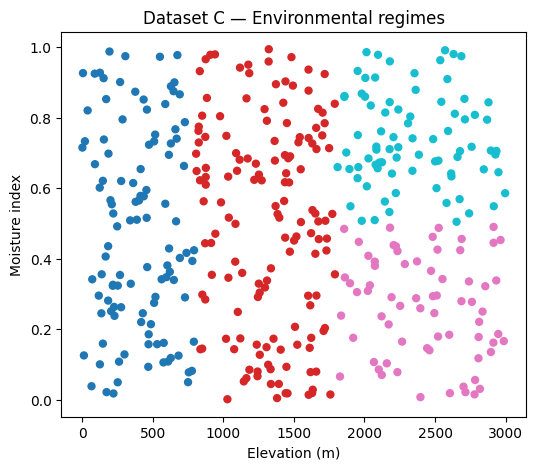

In [30]:
plt.figure(figsize=(6,5))
plt.scatter(elevation, moisture, c=y, cmap="tab10", s=25)

plt.xlabel("Elevation (m)")
plt.ylabel("Moisture index")
plt.title("Dataset C — Environmental regimes")
plt.show()

In [31]:
# Select model and create an instance 
model = DecisionTreeClassifier(max_depth=10, random_state=42)
# Model fit 
model.fit(X_train, y_train)
# Model prediction 
y_pred = model.predict(X_test)

# Model evaluation
accuracy_score(y_test, y_pred)

NameError: name 'X_train' is not defined

In [10]:
tree = DecisionTreeClassifier(max_depth=3).fit(X,y)
pred = tree.predict(X)

print("Accuracy:", accuracy_score(y,pred))

Accuracy: 1.0


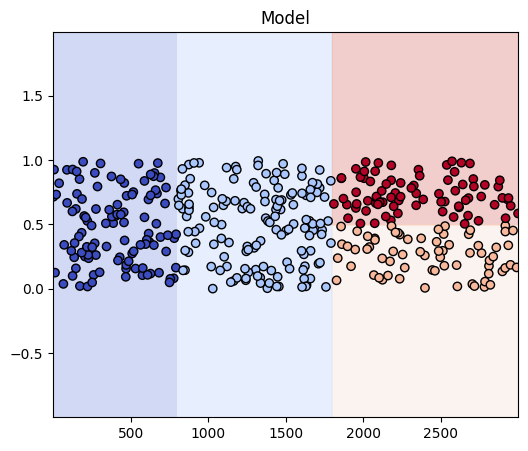

In [12]:
# Plot 
plot_decision_boundary(tree, X, y, title="Model", resolution=300)

# **Dataset D**

In [13]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=300,centers=2,cluster_std=1.3,random_state=4)

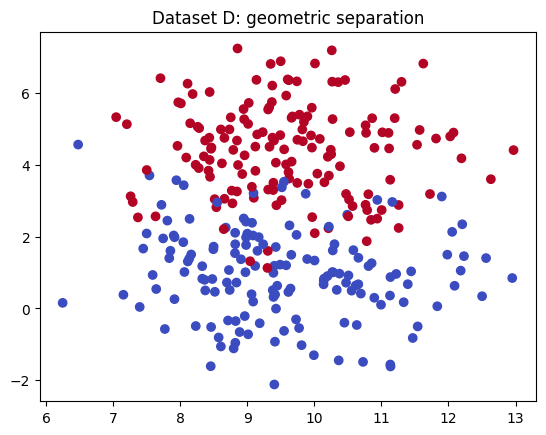

In [14]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm")
plt.title("Dataset D: geometric separation")
plt.show()

In [ ]:
# Select model and create an instance 
pass 
# Model fit 
pass 
# Model prediction 
pass 
# Model evaluation
pass

Accuracy: 0.8888888888888888


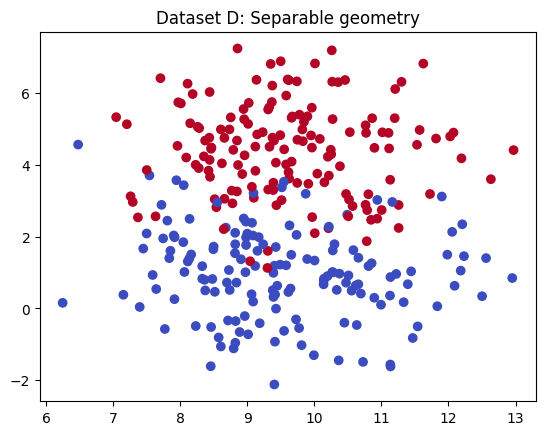

In [15]:
Xtr,Xte,Ytr,Yte = train_test_split(X,y,test_size=0.3)

svm = SVC(kernel='rbf').fit(Xtr,Ytr)
pred = svm.predict(Xte)

print("Accuracy:", accuracy_score(Yte,pred))

plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')
plt.title("Dataset D: Separable geometry")
plt.show()

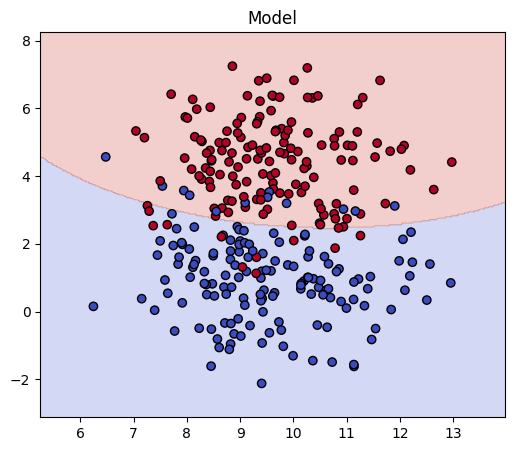

In [17]:
# Plot 
plot_decision_boundary(svm, X, y, title="Model", resolution=300)

In [ ]:
# plot decision boundary 

# **Dataset E**

In [18]:
from sklearn.datasets import make_moons
X,y = make_moons(n_samples=300,noise=0.2,random_state=5)

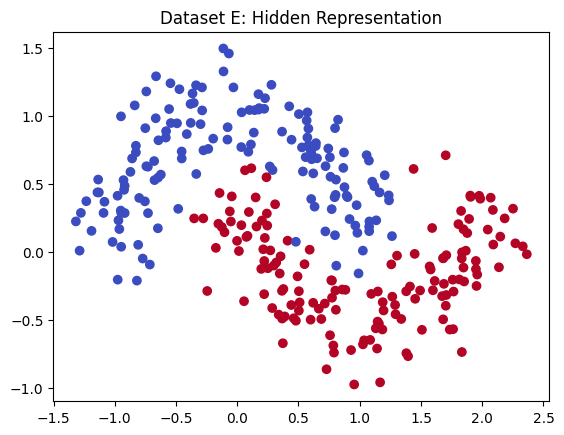

In [19]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm")
plt.title("Dataset E: Hidden Representation")
plt.show()

**XOR — classic “feature missing” problem** 

In [ ]:
# Select model and create an instance 
pass 
# Model fit 
pass 
# Model prediction 
pass 

# Model evaluation
pass


In [22]:
Xtr,Xte,Ytr,Yte = train_test_split(X,y,test_size=0.3)

mlp = MLPClassifier(hidden_layer_sizes=(20,20),max_iter=2000)
mlp.fit(Xtr,Ytr)

pred = mlp.predict(Xte)
print("Accuracy:", accuracy_score(Yte,pred))

Accuracy: 0.9777777777777777


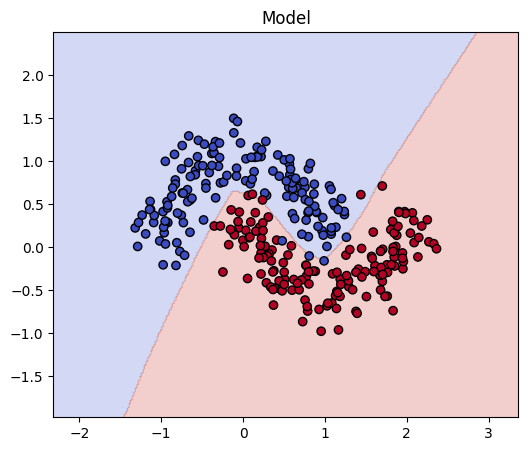

In [23]:
# plot 
plot_decision_boundary(mlp, X, y,"Model")